# Variational data assimilation with diffWOFOST

The overall goal of data assimilation is to combine all possible information, including models, observations, a-priori knowledge, and uncertainty estimates, in order to obtain the best possible estimate of the state of a system.

Variational data assimilation does this by posing one estimation problem over a time window. Instead of correcting the simulation each time a measurement arrives, it searches for a set of uncertain model inputs that makes the simulated trajectory agree as well as possible with the observations while remaining close to prior knowledge.

In practice this means defining a cost function, running the model, measuring the mismatch between model and observations, and adjusting parameters or other controllable quantities until that mismatch is reduced. In crop modelling this is attractive because observational information influences the full seasonal trajectory in a physically consistent way.

This notebook focuses on that variational route using diffWOFOST, the differentiable implementation of WOFOST in PyTorch. Because gradients can be propagated through the simulation, gradient-based optimization can be used directly to solve the assimilation problem.

Earlier notebooks in this series demonstrated the Kalman-filter route, in particular Ensemble Kalman Filter workflows for sequentially updating model states from LAI and soil-moisture observations. Here we take the complementary approach: rather than performing sequential analysis updates, we optimize a differentiable objective over the full assimilation window using the same synthetic observations.

## 1. Background on data assimilation

### 1.1 Sequential versus variational data assimilation

Data-assimilation methods are often grouped into two broad families.

1. **Sequential methods** run the model forward in time until an observation becomes available. At that point an analysis step is carried out that adjusts the model state using the observation and its uncertainty, after which the model is integrated forward again until the next observation arrives.

2. **Variational methods** collect all observations within an assimilation window and then fit the model to those observations by minimizing a cost function. In that optimization, one can adjust parameters, initial conditions, or other attributes that control the simulated trajectory.

A compact formulation is:

$$

J(\theta) = \frac{1}{N} \sum_{i=1}^{N} \left(\frac{y_i^{\mathrm{model}}(\theta) - y_i^{\mathrm{obs}}}{\sigma_i}\right)^2 + \lambda \frac{1}{P} \sum_{j=1}^{P} \left(\frac{\theta_j - \theta_{j,b}}{s_j}\right)^2

$$

where:

- $y_i^{\mathrm{obs}}$ are the observations at the measurement dates,
- $\sigma_i$ are the observation uncertainties,
- $\theta_{j,b}$ are prior or background parameter values,
- $s_j$ are scales used to normalize departures from the prior,
- and $\lambda$ controls the strength of the background penalty.

The first term rewards agreement with observations. The second term discourages unrealistic departures from prior knowledge. Methods such as 3D-Var and 4D-Var differ in how the state and time window are defined, but the central idea is the same: optimize a full trajectory rather than applying isolated corrections.

The earlier `pcse` notebooks illustrate the sequential viewpoint using [Ensemble Kalman Filter (EnKF)](https://github.com/ajwdewit/pcse_notebooks/blob/master/08a%20Data%20assimilation%20with%20the%20EnKF.ipynb) and [EnKF Multistate](https://github.com/ajwdewit/pcse_notebooks/blob/master/08b%20Data%20assimilation%20with%20the%20EnKF%20multistate.ipynb). There, the simulated state is propagated forward until an observation is available, then updated through an analysis step that can introduce a jump in the state trajectory. That Kalman-style workflow is not used here, but it provides a useful contrast for understanding what is specific about the variational approach.

One practical consequence is worth keeping in mind: sequential state updates are inherently non-conservative, because mass or energy can be added or removed when the state is corrected. In a crop model this means that carbon, water, and nutrient balances may no longer close automatically. Variational methods avoid those explicit state jumps and instead search for a trajectory that is generated consistently by the model itself.

### 1.2 Why diffWOFOST is useful here

The main practical difficulty in variational assimilation is optimization. To minimize $J(\theta)$ efficiently, one usually needs gradients of the model outputs with respect to the uncertain inputs. For conventional crop-model implementations, those gradients can be hard to derive or expensive to approximate numerically.

`diffWOFOST` addresses that by implementing the model in PyTorch. As a result:

- model parameters can be treated as trainable variables,
- gradients can flow through the simulation,
- and standard optimizers such as Adam can be used to fit the model to observations.

### 1.3 Scope of this notebook

This notebook uses a synthetic observation record consisting of eight dates of leaf area index (`LAI`) and soil moisture (`SM`). The observations are generated from a perturbed diffWOFOST trajectory so that the variational analysis is asked to recover a reachable target rather than an arbitrary one.

The goal is not to reproduce an operational assimilation system, but to demonstrate the variational workflow clearly:

1. start from a prior simulation,
2. compare it with observations,
3. define a differentiable loss function,
4. optimize a small set of parameters,
5. inspect how the analysed trajectory changes.

## 2. Applying variational data assimilation with diffWOFOST




This section builds the workflow step by step: import the model components, define the observations, run a prior simulation, and then convert that simulation into a variational optimization problem.

In [11]:
%matplotlib inline

from pathlib import Path
import copy
import datetime as dt

import matplotlib
matplotlib.style.use("ggplot")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from diffwofost.physical_models.config import ComputeConfig, Configuration
from diffwofost.physical_models.crop.wofost72 import Wofost72
from diffwofost.physical_models.engine import Engine
from diffwofost.physical_models.soil.classic_waterbalance import WaterbalanceFD
from diffwofost.physical_models.utils import get_test_data, prepare_engine_input

ComputeConfig.set_device("cpu")
ComputeConfig.set_dtype(torch.float64)

print(f"torch version: {torch.__version__}")
print(f"device: {ComputeConfig.get_device()}")
print(f"dtype: {ComputeConfig.get_dtype()}")

torch version: 2.9.0+cu128
device: cpu
dtype: torch.float64


### 2.2 The model, the observations, and a baseline run

We use a local diffWOFOST regression dataset for a winter-wheat water-limited run and construct a synthetic observation schedule for `LAI` and `SM`. The observations are generated from a perturbed reference simulation so that the prior run starts noticeably away from the target trajectory while still remaining physically consistent with the model.


The workflow is deliberately simple:

1. define the model inputs,

2. generate synthetic observations and their uncertainty,

3. run a baseline simulation without assimilation,

4. compare the baseline trajectory with the observations before optimization.

#### 2.2.1 Defining the synthetic observations

Now we build a synthetic observation dataset with eight dates for leaf area index (`LAI`) and soil moisture (`SM`). Instead of prescribing those values by hand, we create them from a reference diffWOFOST run with perturbed parameters and then add small deterministic perturbations to mimic measurement noise.

Using more observation dates makes the assimilation behaviour easier to judge visually. The prior trajectory is sampled more densely across the season, so it becomes clearer where the analysis improves the fit and where mismatches remain.

In [39]:
import diffwofost

project_root = Path(diffwofost.__file__).resolve().parents[2]
test_data_path = project_root / "tests/physical_models/test_data/test_waterlimitedproduction_wofost72_03.yaml"
test_data = get_test_data(test_data_path)

crop_model_params = [
    # Leaf dynamics
    "SPAN",
    "TDWI",
    "TBASE",
    "PERDL",
    "RGRLAI",
    "KDIFTB",
    "SLATB",
    # Phenology
    "TSUMEM",
    "TBASEM",
    "TEFFMX",
    "TSUM1",
    "TSUM2",
    "DLO",
    "DLC",
    "DVSI",
    "DVSEND",
    "DTSMTB",
    # Assimilation
    "AMAXTB",
    "EFFTB",
    "TMPFTB",
    "TMNFTB",
    # Respiration
    "Q10",
    "RMR",
    "RML",
    "RMS",
    "RMO",
    "RFSETB",
    # Evapotranspiration and soil water
    "CFET",
    "DEPNR",
    "IAIRDU",
    "IOX",
    "CRAIRC",
    "SM0",
    "SMW",
    "SMFCF",
    # Root dynamics
    "RDI",
    "RRI",
    "RDMCR",
    "RDMSOL",
    "RDRRTB",
    # Stem dynamics
    "RDRSTB",
    "SSATB",
    # Storage organs
    "SPA",
    # Partitioning
    "FRTB",
    "FLTB",
    "FSTB",
    "FOTB",
    # Conversion factors
    "CVL",
    "CVO",
    "CVR",
    "CVS",
]

crop_calendar = next(iter(test_data["AgroManagement"][0].values()))["CropCalendar"]
crop_start_date = crop_calendar["crop_start_date"]
observation_offsets_days = [14, 28, 42, 56, 70, 84, 98, 112]
dates_of_observation = [
    crop_start_date + dt.timedelta(days=offset)
    for offset in observation_offsets_days
]
observation_index = pd.to_datetime(dates_of_observation)

synthetic_truth_params = {
    "TDWI": 1.55,
    "RGRLAI": 0.028,
    "SPAN": 62.0,
    "DVSI": 0.18,
    "SMFCF": 0.26,
}

truth_provider, truth_weather, truth_agromanagement, truth_external_states = prepare_engine_input(
    test_data, crop_model_params
)
for name, value in synthetic_truth_params.items():
    truth_provider.set_override(name, value, check=False)

truth_config = Configuration(
    CROP=Wofost72,
    SOIL=WaterbalanceFD,
    OUTPUT_VARS=["LAI", "SM"],
)
truth_engine = Engine(config=truth_config)
truth_engine.setup(
    truth_provider,
    truth_weather,
    truth_agromanagement,
    truth_external_states,
 )
truth_engine.run_till_terminate()

truth_rows = []
for row in truth_engine.get_output():
    truth_rows.append({
        key: (float(value.detach().cpu()) if isinstance(value, torch.Tensor) else value)
        for key, value in row.items()
    })
truth_df = pd.DataFrame(truth_rows)
truth_df["day"] = pd.to_datetime(truth_df["day"])
truth_df = truth_df.set_index("day")

phase = np.linspace(0.0, 2.0 * np.pi, len(observation_index), endpoint=False)
lai_noise = 0.05 * np.sin(phase) + 0.02 * np.cos(2.0 * phase)
sm_noise = 0.003 * np.cos(phase) - 0.0015 * np.sin(2.0 * phase)
observed_lai = truth_df.loc[observation_index, "LAI"].to_numpy() * (1.0 + lai_noise)
std_lai = np.maximum(observed_lai * 0.08, 0.05)
observed_sm = truth_df.loc[observation_index, "SM"].to_numpy() + sm_noise
std_sm = np.maximum(observed_sm * 0.04, 0.005)

observation_df = pd.DataFrame({
    "day": observation_index,
    "LAI_obs": observed_lai,
    "LAI_std": std_lai,
    "SM_obs": observed_sm,
    "SM_std": std_sm,
}).set_index("day")
observation_df

,LAI_obs,LAI_std,SM_obs,SM_std
day,,,,
2010-04-10,0.003043,0.050000,0.208649,0.008346
2010-04-24,0.023394,0.050000,0.258154,0.010326
2010-05-08,0.202915,0.050000,0.245363,0.009815
2010-05-22,1.221485,0.097719,0.208439,0.008338
2010-06-05,1.727429,0.138194,0.165255,0.006610
2010-06-19,2.102260,0.168181,0.181892,0.007276
2010-07-03,1.513474,0.121078,0.156659,0.006266
2010-07-17,1.032040,0.082563,0.151530,0.006061


#### 2.2.2 A standard diffWOFOST run




Before assimilating anything, we run the model once with the prior parameter set as a baseline 

In [40]:
wofost72_fd_config = Configuration(
    CROP=Wofost72,
    SOIL=WaterbalanceFD,
    OUTPUT_VARS=[
        "DVS",
        "LAI",
        "SM",
        "TAGP",
        "TRA",
        "TWLV",
        "TWRT",
        "TWSO",
        "TWST",
    ],
)

def load_engine_inputs():
    return prepare_engine_input(test_data, crop_model_params)

def scalarize(value):
    if isinstance(value, torch.Tensor):
        return float(value.detach().cpu())
    return value

def results_to_frame(results):
    rows = []
    for row in results:
        rows.append({key: (value if key == "day" else scalarize(value)) for key, value in row.items()})
    frame = pd.DataFrame(rows)
    frame["day"] = pd.to_datetime(frame["day"])
    return frame.set_index("day")

provider, weather, agromanagement, external_states = load_engine_inputs()
baseline_engine = Engine(config=wofost72_fd_config)
baseline_engine.setup(provider, weather, agromanagement, external_states)
baseline_engine.run_till_terminate()
baseline_results = baseline_engine.get_output()
baseline_df = results_to_frame(baseline_results)

baseline_df.loc[observation_index, ["LAI", "SM", "TWST", "TWSO", "TAGP"]]

,LAI,SM,TWST,TWSO,TAGP
2010-04-10,0.001088,0.255609,0.098209,0.000000,0.644744
2010-04-24,0.009090,0.315091,1.214141,0.000000,5.762423
2010-05-08,0.081383,0.305397,18.077028,0.000000,58.771549
2010-05-22,0.608296,0.279450,193.851782,0.000000,498.003214
2010-06-05,1.969383,0.218582,885.029989,77.574591,1997.245638
2010-06-19,2.978132,0.219255,1570.371395,1327.981747,4544.782245
2010-07-03,2.393322,0.174268,1682.617640,1979.603111,5382.565430
2010-07-17,1.634733,0.156955,1682.617640,1979.603111,5382.565430


#### 2.2.3 Plotting the baseline model against the observations




This figure shows how the prior simulation differs from the observations before any optimization is applied.

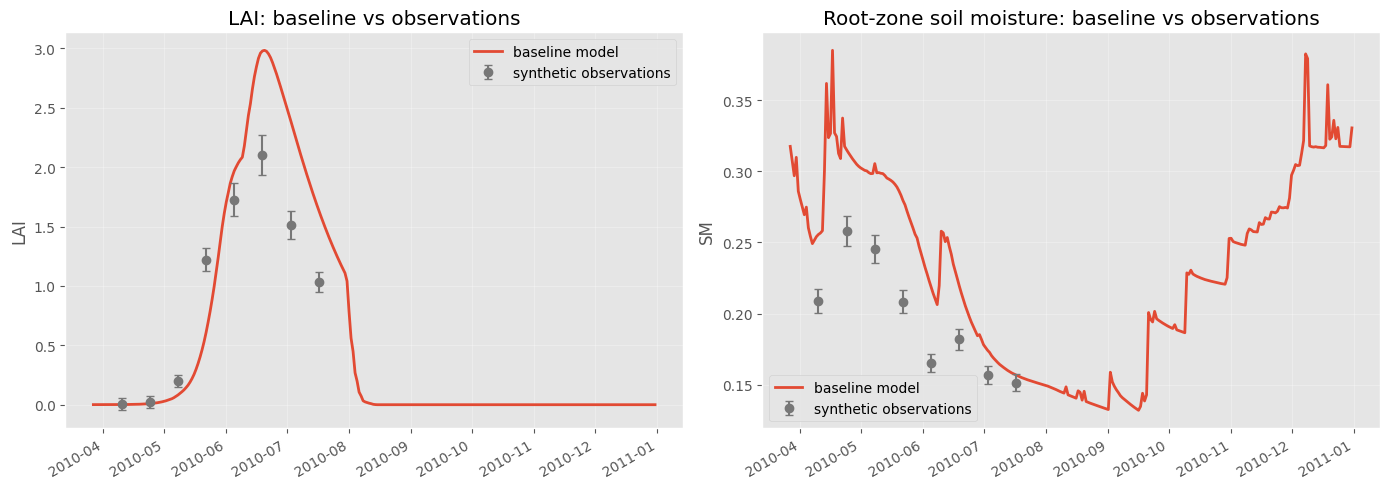

In [45]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), sharex=True)

axes[0].plot(
    baseline_df.index,
    baseline_df["LAI"].to_numpy(),
    color="C0",
    linewidth=2.0,
    label="baseline model",
)
axes[0].errorbar(
    observation_index,
    observed_lai,
    yerr=std_lai,
    fmt="o",
    color="C3",
    capsize=3,
    label="synthetic observations",
)
axes[0].set_title("LAI: baseline vs observations")
axes[0].set_ylabel("LAI")
axes[0].legend()

axes[1].plot(
    baseline_df.index,
    baseline_df["SM"].to_numpy(),
    color="C0",
    linewidth=2.0,
    label="baseline model",
)
axes[1].errorbar(
    observation_index,
    observed_sm,
    yerr=std_sm,
    fmt="o",
    color="C3",
    capsize=3,
    label="synthetic observations",
)
axes[1].set_title("Root-zone soil moisture: baseline vs observations")
axes[1].set_ylabel("SM")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 2.3 Setting up the variational problem

In this section, we turn the crop simulation into an optimization problem. Instead of accepting the prior parameter set as fixed, we choose a small number of uncertain model parameters, treat them as trainable quantities, and adjust them so that the simulated trajectory agrees better with the prescribed `LAI` and `SM` observations over the full assimilation window.


We optimize five bounded parameters:

- `TDWI`: total initial dry weight,

- `RGRLAI`: relative growth rate of leaf area,

- `SPAN`: leaf life span,

- `DVSI`: initial development stage,

- `SMFCF`: soil moisture at field capacity.


The cost function contains:

- an observation term for `LAI`,

- an observation term for `SM`,

- and a weak background penalty that keeps the optimized values close to the prior parameter values from the YAML setup.

#### 2.3.1 Defining trainable parameter helpers

Before wrapping the full simulation, we first define the tensors and helper objects used by the optimizer. The observation arrays are converted to PyTorch tensors so they can be used directly in the loss function.

This cell also defines `BoundedParameter`, a small helper for scalar parameters that should remain inside a prescribed interval during optimization. It stores an unconstrained internal variable and maps it into the chosen range with a sigmoid transform, so the parameter stays differentiable while still respecting the specified bounds.

In [41]:
obs_lai_t = torch.tensor(observed_lai, dtype=ComputeConfig.get_dtype(), device=ComputeConfig.get_device())
obs_lai_std_t = torch.tensor(std_lai, dtype=ComputeConfig.get_dtype(), device=ComputeConfig.get_device())
obs_sm_t = torch.tensor(observed_sm, dtype=ComputeConfig.get_dtype(), device=ComputeConfig.get_device())
obs_sm_std_t = torch.tensor(std_sm, dtype=ComputeConfig.get_dtype(), device=ComputeConfig.get_device())

TDWI_MIN, TDWI_MAX, TDWI_INIT = (0.10, 2.50, 0.51)
RGRLAI_MIN, RGRLAI_MAX, RGRLAI_INIT = (0.0075, 0.05, 0.016)
SPAN_MIN, SPAN_MAX, SPAN_INIT = (10.0, 90.0, 35.0)
DVSI_MIN, DVSI_MAX, DVSI_INIT = (-0.10, 0.80, 0.0)
SMFCF_MIN, SMFCF_MAX, SMFCF_INIT = (0.18, 0.45, 0.3175)

class BoundedParameter(torch.nn.Module):
    def __init__(self, low, high, init_value):
        super().__init__()
        self.low = low
        self.high = high

        init_norm = (init_value - low) / (high - low)
        init_norm = min(max(init_norm, 1e-6), 1 - 1e-6)

        self.raw = torch.nn.Parameter(
            torch.logit(
                torch.tensor(
                    init_norm,
                    dtype=ComputeConfig.get_dtype(),
                    device=ComputeConfig.get_device(),
                ),
                eps=1e-6,
            )
        )

    def forward(self):
        return self.low + (self.high - self.low) * torch.sigmoid(self.raw)

#### 2.3.2 Wrapping diffWOFOST in a trainable module

This code block defines the `VariationalDiffWofost72` wrapper around the crop model. Its role is to hold the fixed model inputs, create the five trainable parameters (`TDWI`, `RGRLAI`, `SPAN`, `DVSI`, and `SMFCF`), rerun diffWOFOST with those parameter overrides, and return the simulated `LAI` and `SM` values at the observation dates.

In this way, one forward pass corresponds to one complete model evaluation for the current parameter values, and the optimizer can use those outputs to compute the mismatch with the observations.

In [33]:
class VariationalDiffWofost72(torch.nn.Module):
    def __init__(
        self,
        crop_model_params_provider,
        weather_data_provider,
        agro_management_inputs,
        external_states,
        config,
    ):
        super().__init__()
        self.base_provider = crop_model_params_provider
        self.weather_data_provider = weather_data_provider
        self.agro_management_inputs = agro_management_inputs
        self.external_states = external_states
        self.config = config
        self.engine = Engine(config=config)

        self.tdwi = BoundedParameter(TDWI_MIN, TDWI_MAX, init_value=TDWI_INIT)
        self.rgrlai = BoundedParameter(RGRLAI_MIN, RGRLAI_MAX, init_value=RGRLAI_INIT)
        self.span = BoundedParameter(SPAN_MIN, SPAN_MAX, init_value=SPAN_INIT)
        self.dvsi = BoundedParameter(DVSI_MIN, DVSI_MAX, init_value=DVSI_INIT)
        self.smfcf = BoundedParameter(SMFCF_MIN, SMFCF_MAX, init_value=SMFCF_INIT)

    def parameter_dict(self):
        return {
            "TDWI": self.tdwi(),
            "RGRLAI": self.rgrlai(),
            "SPAN": self.span(),
            "DVSI": self.dvsi(),
            "SMFCF": self.smfcf(),
        }

    def run_model(self, overrides):
        provider = copy.deepcopy(self.base_provider)
        for name, value in overrides.items():
            provider.set_override(name, value, check=False)

        engine = self.engine.setup(
            provider,
            self.weather_data_provider,
            self.agro_management_inputs,
            self.external_states,
        )
        engine.run_till_terminate()
        return engine.get_output()

    def forward(self):
        overrides = self.parameter_dict()
        results = self.run_model(overrides)
        by_day = {row["day"]: row for row in results}
        lai_at_obs = torch.stack([by_day[day]["LAI"] for day in dates_of_observation])
        sm_at_obs = torch.stack([by_day[day]["SM"] for day in dates_of_observation])
        return lai_at_obs, sm_at_obs, overrides

#### 2.3.3 Initializing the variational model

After defining the helper class and wrapper module, we prepare the actual optimization problem. We first reload the model inputs, then store the prior values of the five parameters that we want to optimize. These prior values are used later in the background penalty, which discourages the optimizer from drifting too far away from the original parameter set.

The `background_scales` dictionary sets the characteristic size of an acceptable perturbation for each parameter. Finally, we instantiate `opt_model`, which is the trainable wrapper around diffWOFOST. In this version, the optimizer updates five bounded parameters through the same `BoundedParameter` pattern used above.

In [42]:
provider_opt, weather_opt, agro_opt, external_opt = load_engine_inputs()
prior_params = {
    "TDWI": provider_opt["TDWI"].detach().clone(),
    "RGRLAI": provider_opt["RGRLAI"].detach().clone(),
    "SPAN": provider_opt["SPAN"].detach().clone(),
    "DVSI": provider_opt["DVSI"].detach().clone(),
    "SMFCF": provider_opt["SMFCF"].detach().clone(),
}
background_scales = {
    "TDWI": torch.tensor(0.20, dtype=ComputeConfig.get_dtype()),
    "RGRLAI": torch.tensor(0.004, dtype=ComputeConfig.get_dtype()),
    "SPAN": torch.tensor(10.0, dtype=ComputeConfig.get_dtype()),
    "DVSI": torch.tensor(0.25, dtype=ComputeConfig.get_dtype()),
    "SMFCF": torch.tensor(0.06, dtype=ComputeConfig.get_dtype()),
}

opt_model = VariationalDiffWofost72(
    provider_opt,
    weather_opt,
    agro_opt,
    external_opt,
    wofost72_fd_config,
 )

{name: float(value) for name, value in prior_params.items()}

{'TDWI': 0.51, 'RGRLAI': 0.016, 'SPAN': 35.0, 'DVSI': 0.0, 'SMFCF': 0.3175}

In [43]:
optimizer = torch.optim.Adam(opt_model.parameters(), lr=0.05)
history = []
best_state = None
best_loss = float("inf")
lai_weight = 2.0
sm_weight = 1.0
background_weight = 0.01

max_steps = 80
patience = 15
min_improvement = 1e-4
steps_without_improvement = 0

for step in range(max_steps + 1):
    optimizer.zero_grad()
    lai_pred, sm_pred, params = opt_model()

    lai_loss = torch.mean(((lai_pred - obs_lai_t) / obs_lai_std_t) ** 2)
    sm_loss = torch.mean(((sm_pred - obs_sm_t) / obs_sm_std_t) ** 2)
    background_loss = torch.mean(
        torch.stack([
            ((params[name] - prior_params[name]) / background_scales[name]) ** 2
            for name in params
        ])
    )
    loss = lai_weight * lai_loss + sm_weight * sm_loss + background_weight * background_loss
    loss.backward()
    optimizer.step()

    current_loss = float(loss.detach().cpu())
    snapshot = {name: float(value.detach().cpu()) for name, value in params.items()}
    history.append({
        "step": step,
        "loss": current_loss,
        "lai_loss": float(lai_loss.detach().cpu()),
        "sm_loss": float(sm_loss.detach().cpu()),
        "background_loss": float(background_loss.detach().cpu()),
        **snapshot,
    })

    if best_loss - current_loss > min_improvement:
        best_loss = current_loss
        best_state = {name: value.detach().clone() for name, value in params.items()}
        steps_without_improvement = 0
    else:
        steps_without_improvement += 1

    if step % 10 == 0 or step == max_steps:
        print(
            f"step={step:03d} loss={current_loss:.4f} "
            f"lai={history[-1]['lai_loss']:.4f} sm={history[-1]['sm_loss']:.4f} "
            f"TDWI={snapshot['TDWI']:.4f} RGRLAI={snapshot['RGRLAI']:.4f} "
            f"SPAN={snapshot['SPAN']:.4f} DVSI={snapshot['DVSI']:.4f} "
            f"SMFCF={snapshot['SMFCF']:.4f}"
        )

    if steps_without_improvement >= patience:
        print(f"Stopping early at step {step:03d}: loss improvement < {min_improvement} for {patience} steps.")
        break

history_df = pd.DataFrame(history)
history_df.tail()

step=000 loss=79.4331 lai=22.7060 sm=34.0211 TDWI=0.5100 RGRLAI=0.0160 SPAN=35.0000 DVSI=0.0000 SMFCF=0.3175
step=010 loss=22.0221 lai=7.3988 sm=7.2213 TDWI=0.7095 RGRLAI=0.0181 SPAN=32.7896 DVSI=-0.0011 SMFCF=0.2851
step=020 loss=5.3936 lai=2.3870 sm=0.6061 TDWI=0.9623 RGRLAI=0.0188 SPAN=40.8494 DVSI=-0.0009 SMFCF=0.2624
step=030 loss=3.0593 lai=1.3493 sm=0.3255 TDWI=1.2310 RGRLAI=0.0190 SPAN=52.0421 DVSI=0.0001 SMFCF=0.2543
step=040 loss=1.0788 lai=0.3904 sm=0.2350 TDWI=1.4553 RGRLAI=0.0190 SPAN=62.4049 DVSI=0.0004 SMFCF=0.2558
step=050 loss=0.4871 lai=0.1403 sm=0.1218 TDWI=1.5956 RGRLAI=0.0189 SPAN=68.6776 DVSI=-0.0001 SMFCF=0.2591
step=060 loss=0.5089 lai=0.1523 sm=0.1096 TDWI=1.6584 RGRLAI=0.0188 SPAN=70.9119 DVSI=-0.0001 SMFCF=0.2596
step=070 loss=0.4338 lai=0.0960 sm=0.1448 TDWI=1.6774 RGRLAI=0.0187 SPAN=71.0216 DVSI=0.0001 SMFCF=0.2580
step=080 loss=0.4377 lai=0.0807 sm=0.1794 TDWI=1.6824 RGRLAI=0.0186 SPAN=70.6185 DVSI=-0.0000 SMFCF=0.2571


,step,loss,lai_loss,sm_loss,background_loss,TDWI,RGRLAI,SPAN,DVSI,SMFCF
76,76,0.433614,0.082764,0.171061,9.702530,1.680904,0.018618,70.781811,0.000059,0.257335
77,77,0.434897,0.081945,0.173999,9.700871,1.681305,0.018606,70.739824,0.000036,0.257265
78,78,0.436072,0.081351,0.176381,9.698910,1.681679,0.018593,70.698494,-0.000014,0.257210
79,79,0.437026,0.080934,0.178190,9.696745,1.682032,0.018581,70.658026,-0.000047,0.257168
80,80,0.437687,0.080657,0.179429,9.694444,1.682369,0.018568,70.618525,-0.000041,0.257140


In [44]:
with torch.no_grad():
    analysed_results = opt_model.run_model(best_state)

analysis_df = results_to_frame(analysed_results)
comparison_at_obs = pd.DataFrame({
    "LAI_obs": observed_lai,
    "LAI_baseline": baseline_df.loc[observation_index, "LAI"].to_numpy(),
    "LAI_analysis": analysis_df.loc[observation_index, "LAI"].to_numpy(),
    "SM_obs": observed_sm,
    "SM_baseline": baseline_df.loc[observation_index, "SM"].to_numpy(),
    "SM_analysis": analysis_df.loc[observation_index, "SM"].to_numpy(),
}, index=observation_index)

print("Best parameter values")
for name, value in best_state.items():
    print(f"{name}: {float(value):.4f} (prior {float(prior_params[name]):.4f})")

comparison_at_obs

Best parameter values
TDWI: 1.6789 (prior 0.5100)
RGRLAI: 0.0187 (prior 0.0160)
SPAN: 70.9483 (prior 35.0000)
DVSI: -0.0001 (prior 0.0000)
SMFCF: 0.2578 (prior 0.3175)


,LAI_obs,LAI_baseline,LAI_analysis,SM_obs,SM_baseline,SM_analysis
2010-04-10,0.003043,0.001088,0.003199,0.208649,0.255609,0.203401
2010-04-24,0.023394,0.009090,0.023996,0.258154,0.315091,0.255282
2010-05-08,0.202915,0.081383,0.208674,0.245363,0.305397,0.242864
2010-05-22,1.221485,0.608296,1.219628,0.208439,0.279450,0.206002
2010-06-05,1.727429,1.969383,1.671038,0.165255,0.218582,0.166713
2010-06-19,2.102260,2.978132,2.140178,0.181892,0.219255,0.184549
2010-07-03,1.513474,2.393322,1.594719,0.156659,0.174268,0.156213
2010-07-17,1.032040,1.634733,1.047490,0.151530,0.156955,0.147568


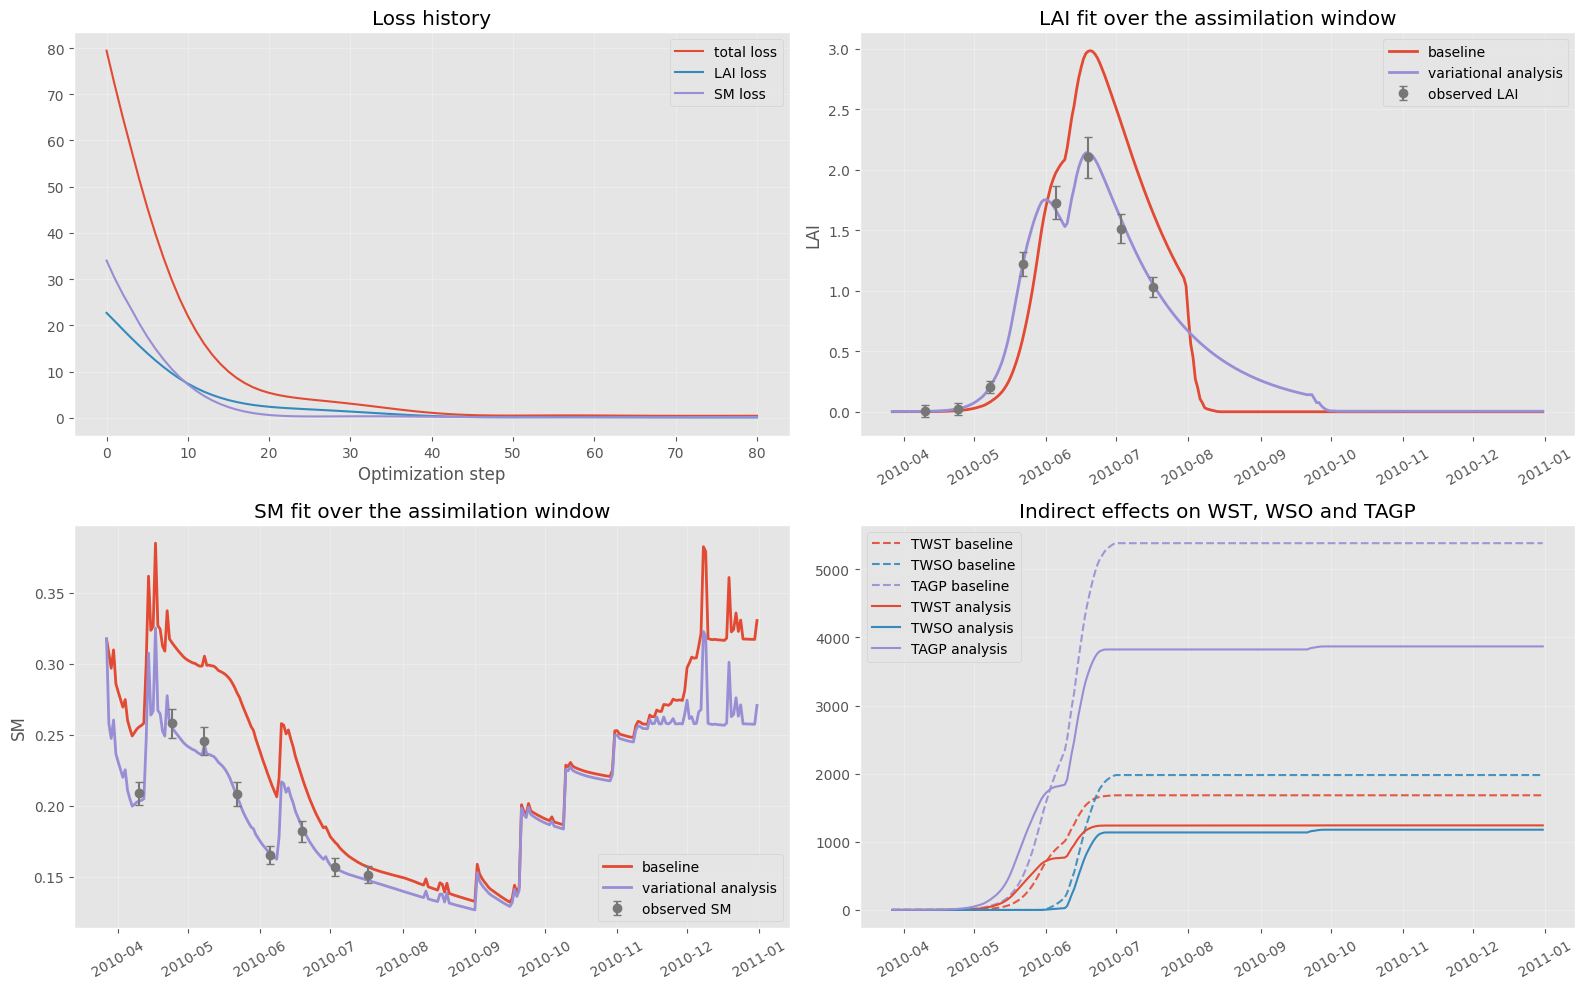

In [46]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

axes[0, 0].plot(history_df["step"].to_numpy(), history_df["loss"].to_numpy(), label="total loss")
axes[0, 0].plot(history_df["step"].to_numpy(), history_df["lai_loss"].to_numpy(), label="LAI loss")
axes[0, 0].plot(history_df["step"].to_numpy(), history_df["sm_loss"].to_numpy(), label="SM loss")
axes[0, 0].set_title("Loss history")
axes[0, 0].set_xlabel("Optimization step")
axes[0, 0].legend()

axes[0, 1].plot(
    baseline_df.index,
    baseline_df["LAI"].to_numpy(),
    color="C0",
    linewidth=2.0,
    label="baseline",
)
axes[0, 1].plot(
    analysis_df.index,
    analysis_df["LAI"].to_numpy(),
    color="C2",
    linewidth=2.0,
    label="variational analysis",
)
axes[0, 1].errorbar(
    observation_index,
    observed_lai,
    yerr=std_lai,
    fmt="o",
    color="C3",
    capsize=3,
    label="observed LAI",
)
axes[0, 1].set_title("LAI fit over the assimilation window")
axes[0, 1].set_ylabel("LAI")
axes[0, 1].legend()

axes[1, 0].plot(
    baseline_df.index,
    baseline_df["SM"].to_numpy(),
    color="C0",
    linewidth=2.0,
    label="baseline",
)
axes[1, 0].plot(
    analysis_df.index,
    analysis_df["SM"].to_numpy(),
    color="C2",
    linewidth=2.0,
    label="variational analysis",
)
axes[1, 0].errorbar(
    observation_index,
    observed_sm,
    yerr=std_sm,
    fmt="o",
    color="C3",
    capsize=3,
    label="observed SM",
)
axes[1, 0].set_title("SM fit over the assimilation window")
axes[1, 0].set_ylabel("SM")
axes[1, 0].legend()

axes[1, 1].plot(
    baseline_df.index,
    baseline_df["TWST"].to_numpy(),
    linestyle="--",
    color="C0",
    alpha=0.9,
    label="TWST baseline",
)
axes[1, 1].plot(
    baseline_df.index,
    baseline_df["TWSO"].to_numpy(),
    linestyle="--",
    color="C1",
    alpha=0.9,
    label="TWSO baseline",
)
axes[1, 1].plot(
    baseline_df.index,
    baseline_df["TAGP"].to_numpy(),
    linestyle="--",
    color="C2",
    alpha=0.9,
    label="TAGP baseline",
)
axes[1, 1].plot(
    analysis_df.index,
    analysis_df["TWST"].to_numpy(),
    color="C0",
    label="TWST analysis",
)
axes[1, 1].plot(
    analysis_df.index,
    analysis_df["TWSO"].to_numpy(),
    color="C1",
    label="TWSO analysis",
)
axes[1, 1].plot(
    analysis_df.index,
    analysis_df["TAGP"].to_numpy(),
    color="C2",
    label="TAGP analysis",
)
axes[1, 1].set_title("Indirect effects on WST, WSO and TAGP")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

for ax in (axes[0, 1], axes[1, 0], axes[1, 1]):
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 3. Visualizing and interpreting the variational analysis




The optimized trajectory can be interpreted through a few key points:



1. **The analysed trajectory is still a model trajectory.** The simulation is not patched locally at the observation times. Instead, the model is rerun with a better parameter set.

2. **Multiple variables can be fitted together.** Here `LAI` and `SM` appear in the same cost function, so the optimizer balances both observational constraints simultaneously.

3. **Unobserved variables can still respond.** Quantities such as `WST`, `WSO`, and `TAGP` are not observed directly in the loss, but they change because the optimized parameters alter the full crop trajectory.

4. **Regularization matters.** The background term prevents the optimizer from drifting too far from the prior parameter values, which is important when observations are sparse or noisy.



Natural extensions are to widen the assimilation window, optimize more parameters, introduce parameter covariances, or replace the simple weighted least-squares objective with a richer statistical formulation.